### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | _[Enter Your Full Name]_     |
| 🆔 **USN**              | _[Enter Your USN]_           |
| **Section**        | _[Enter Your Section]_ |
| **Programme**   | B.Tech(H)             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


**Task 01:** Load the important libraries

In [3]:
pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
pip install opencv-python


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Ankitha Hathwar\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [7]:
!pip install tensorflow



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: THESE PACKAGES DO NOT MATCH THE HASHES FROM THE REQUIREMENTS FILE. If you have updated the package versions, please update the hashes. Otherwise, examine the package contents carefully; someone may have tampered with them.
    unknown package:
        Expected sha256 27ba0682572b1e50a0db1ee74cfb787eafcfdb1b751bbbf401fed62fe32a92e0
             Got        d4ec3acd9815a1e1bc51aea841ea9b277779813ac8bbfff7c9b96ff29c41ec03




  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 4.2 MB/s eta 0:01:25
   ---------------------------------------- 0.8/350.9 MB 3.3 MB/s eta 0:01:45
   ---------------------------------------- 1.6/350.9 MB 2.5 MB/s eta 0:02:18
   ---------------------------------------- 1.6/350.9 MB 2.5 MB/s eta 0:02:18
   ---------------------------------------- 2.6/350.9 MB 2.6 MB/s eta 0:02:14
   ---------------------------------------- 3.7/350.9 MB 3.1 MB/s eta 0:01:52
    --------------------------------------- 4.5/350.9 MB 3.1 MB/s eta 0:01:54
    --------------------------------------- 5.5/350.9 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 6.3/350.9 MB 3.4 MB/s eta 0:01:43
    --------------------------------------- 7.3/350.9 MB 3.7 MB/s eta 0:01:34
    --------------------------------------- 8.1/350.9 MB 3.6 MB/s eta 0:01:36

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import cv2
from tensorflow import keras
from tensorflow.keras import layers,models

#Write your code below this line

**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [8]:
import tensorflow as tf


In [12]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 319s 1us/step
data_dir = C:\Users\Ankitha Hathwar\.keras\datasets\flower_photos


**Task 03:** Data Exploration

In [14]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = C:\Users\Ankitha Hathwar\.keras\datasets\flower_photos\flower_photos


In [15]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [16]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [17]:
IMG_SIZE = (224, 224)      # Fill
BATCH_SIZE = 32             # Fill
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

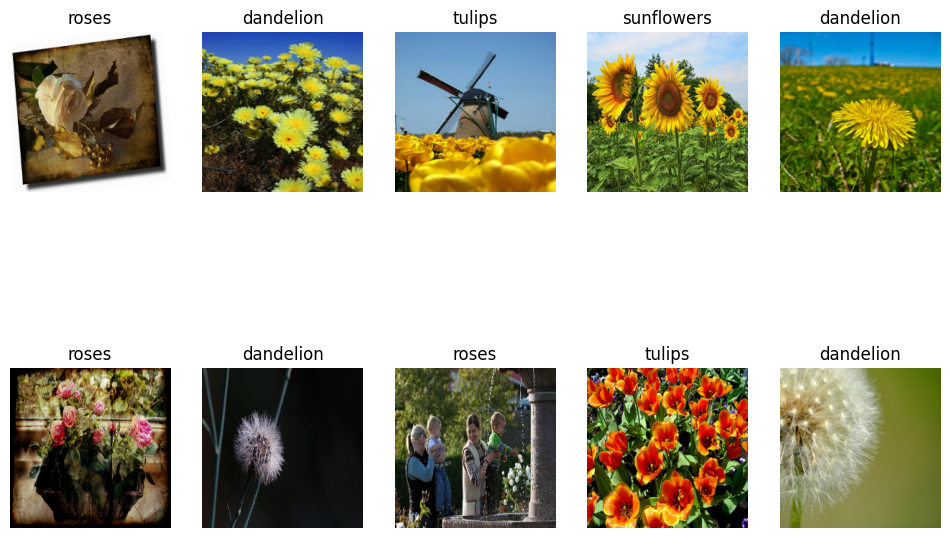

In [18]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

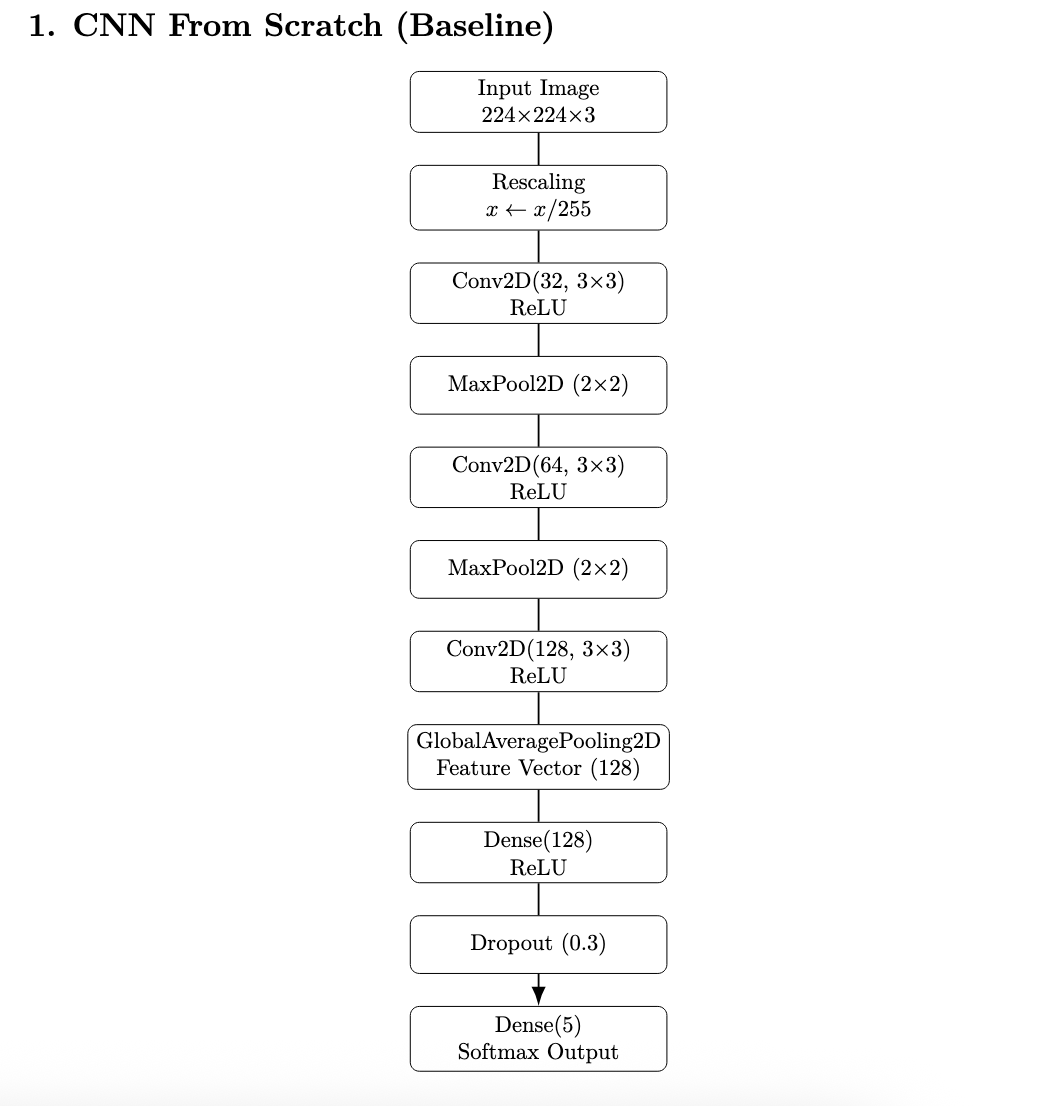

In [20]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [21]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.3887 - loss: 1.3951 - val_accuracy: 0.4242 - val_loss: 1.3450
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4508 - loss: 1.2512 - val_accuracy: 0.4646 - val_loss: 1.2145
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4969 - loss: 1.1851 - val_accuracy: 0.5409 - val_loss: 1.1631
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5198 - loss: 1.1408 - val_accuracy: 0.5551 - val_loss: 1.1468
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5532 - loss: 1.0989 - val_accuracy: 0.5442 - val_loss: 1.1406
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.5779 - loss: 1.0451 - val_accuracy: 0.5638 - val_loss: 1.0717
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5990 - loss: 1.0197 - val_accuracy: 0.5823 - val_loss: 1.0381
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6182 - loss: 0.9892 - val_accuracy: 0.6020 - v

Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

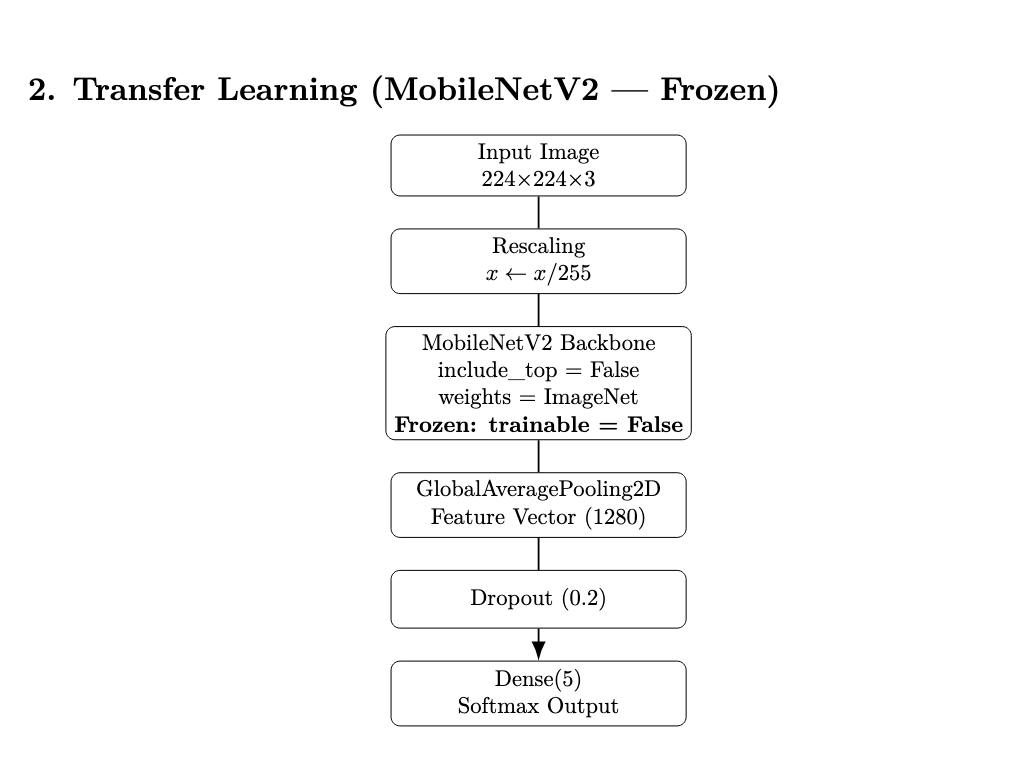

In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Removing output layer
    weights = "imagenet"         # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # ONly last 3 layers are being trained. Cuz basemodel is used fpr only feature extraction
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

In [24]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [25]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 81s 801ms/step - accuracy: 0.6796 - loss: 0.8453 - val_accuracy: 0.8113 - val_loss: 0.5230
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 63s 727ms/step - accuracy: 0.8391 - loss: 0.4652 - val_accuracy: 0.8528 - val_loss: 0.4304
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 715ms/step - accuracy: 0.8638 - loss: 0.3777 - val_accuracy: 0.8724 - val_loss: 0.3916
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 63s 726ms/step - accuracy: 0.8928 - loss: 0.3258 - val_accuracy: 0.8779 - val_loss: 0.3642
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 710ms/step - accuracy: 0.9063 - loss: 0.2861 - val_accuracy: 0.8877 - val_loss: 0.3591
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 719ms/step - accuracy: 0.9201 - loss: 0.2562 - val_accuracy: 0.8855 - val_loss: 0.3415
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 65s 747ms/step - accuracy: 0.9179 - loss: 0.2431 - val_accuracy: 0.8877 - val_loss: 0.3431
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 62s 709ms/step - accuracy: 0.9226 - loss: 0.2292 - val_accu

#Compare the Learning curves of both

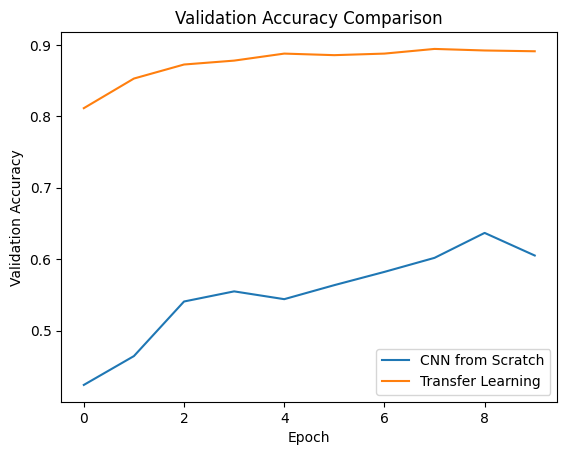

In [26]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [27]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,10,110405,0.636859
1,Transfer Learning,10,2264389,0.894220


## Answer the following questions:

1. Which model converges faster?
2. Which model shows higher validation accuracy?
3. Does CNN from scratch show signs of overfitting? Explain.
4. Why does TL have many parameters but few trainable ones?
5. Why does freezing layers reduce training time?
6. Which model requires more data to train effectively?

1.Transfer Learning (MobileNetV2) converges faster because it uses pre-trained weights that already learned general image features.

2.The Transfer Learning model shows higher validation accuracy compared to the CNN trained from scratch.

3.Yes, the CNN from scratch shows signs of overfitting because the training accuracy becomes higher than the validation accuracy, indicating it learns the training data better than unseen data.

4.Transfer Learning models have many parameters because they are deep networks, but only a few are trainable since most layers are frozen and only the final layers are updated.

5.Freezing layers reduces training time because the model does not compute gradients or update weights for those layers during backpropagation.

6.The CNN trained from scratch requires more data to train effectively because it must learn all image features from the beginning.

## Prediction on Validation Data

In [28]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [29]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))

print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.6052
Transfer Learning Test Accuracy: 0.8909


<Figure size 640x480 with 0 Axes>

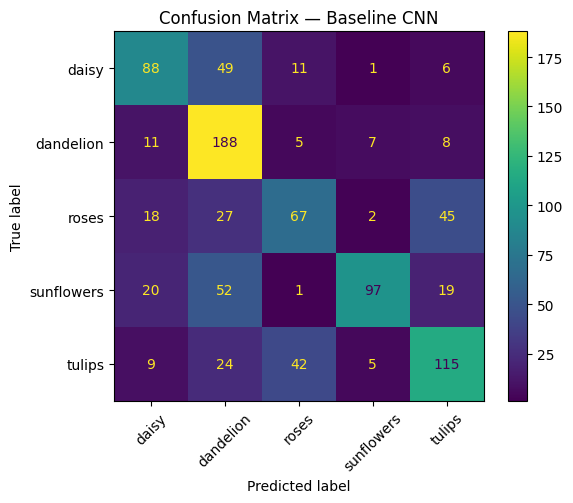

<Figure size 640x480 with 0 Axes>

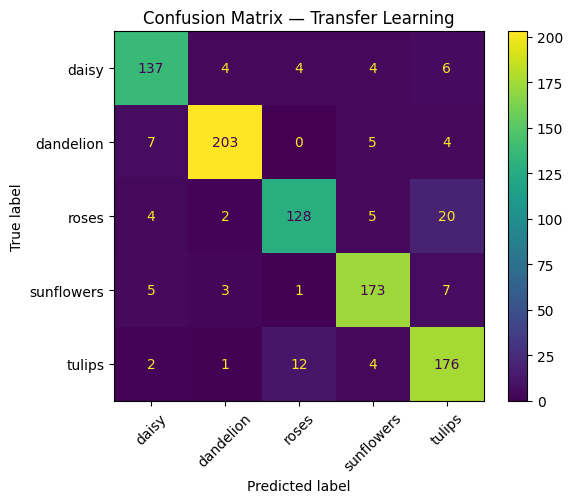

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?
2. Which class shows highest accuracy in TL model?
3. Why might “roses” be harder to classify than “sunflowers”?

1.The CNN from scratch most commonly confuses visually similar classes such as daisy and dandelion, since both flowers have similar shapes and colors.

2.In the Transfer Learning (MobileNetV2) model, sunflowers typically show the highest accuracy because they have distinctive features like bright yellow petals and a large dark center.

3.“Roses” may be harder to classify than “sunflowers” because roses appear in many colors, shapes, and backgrounds, while sunflowers have a more consistent and distinctive appearance, making them easier for the model to recognize.

In [31]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.60      0.57      0.58       155
   dandelion       0.55      0.86      0.67       219
       roses       0.53      0.42      0.47       159
  sunflowers       0.87      0.51      0.64       189
      tulips       0.60      0.59      0.59       195

    accuracy                           0.61       917
   macro avg       0.63      0.59      0.59       917
weighted avg       0.63      0.61      0.60       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.88      0.88      0.88       155
   dandelion       0.95      0.93      0.94       219
       roses       0.88      0.81      0.84       159
  sunflowers       0.91      0.92      0.91       189
      tulips       0.83      0.90      0.86       195

    accuracy                           0.89       917
   macro avg       0.89      0.89      0.89       917
weighted avg    

## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?
2.	How much did overall accuracy improve using TL?
3.	Why does precision differ from recall?

1.The daisy (or dandelion) class typically has the lowest F1-score in the baseline CNN because these classes have very similar visual features, making them harder for the model to distinguish.

2.The overall accuracy improved after using Transfer Learning (MobileNetV2) because the pre-trained model already learned general image features, leading to better performance compared to the CNN trained from scratch.

3.Precision differs from recall because they measure different aspects of classification performance. Precision measures how many predicted positives are actually correct, while recall measures how many actual positive samples were correctly identified by the model.

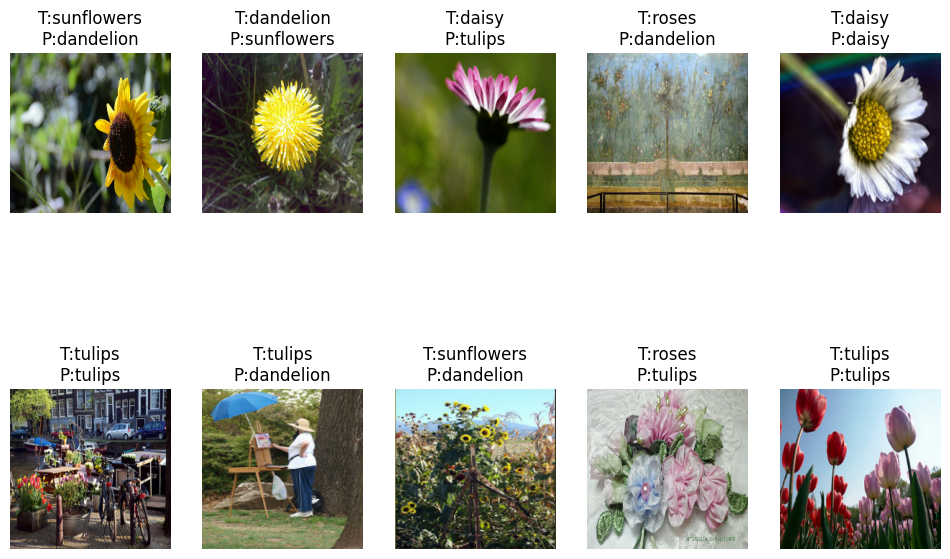

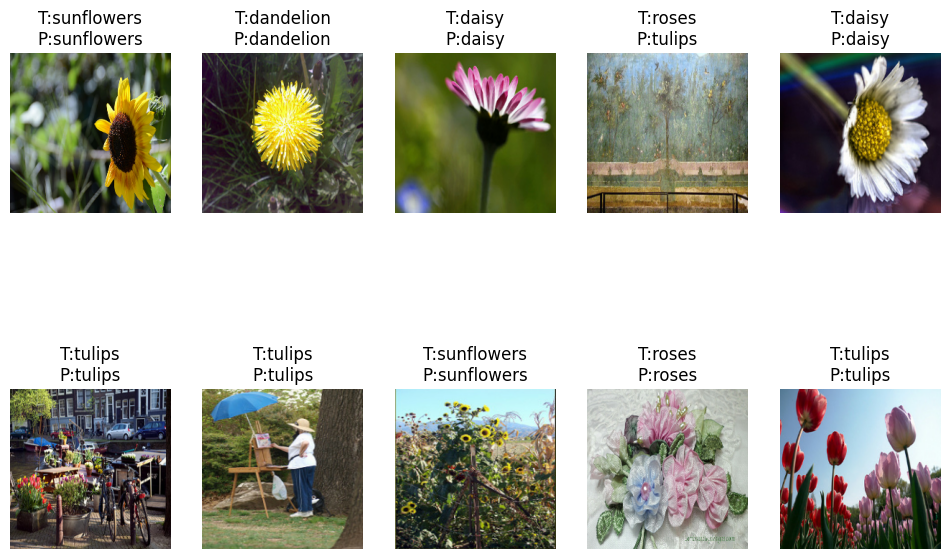

In [32]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:

	1.	Why does TL have many parameters but few trainable ones?
	2.	Why does freezing layers reduce training time?
	3.	Which model requires more data to train effectively?

1.Transfer Learning models have many parameters because they are deep pre-trained networks, but only a few are trainable since most layers are frozen and only the final classification layers are updated.

2.Freezing layers reduces training time because the model does not compute gradients or update weights for those layers during backpropagation.

3.The CNN trained from scratch requires more data to train effectively because it must learn all image features from the beginning without using pre-trained knowledge.

## Test on new data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


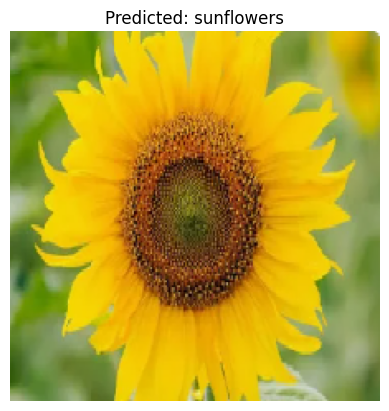

This image most likely belongs to sunflowers with a 39.65 percent confidence.


In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Pick a path to an actual image in your downloaded dataset
# (Make sure this file path exists on your computer)
img_path = 'image.png' 

# 2. Load and Preprocess the image
# We use 224x224 because that is what MobileNetV2 (Transfer Learning) expects
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

# 3. Predict using the Transfer Learning model (tl_model)
predictions = tl_model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# 4. Output the Result
plt.imshow(img)
plt.title(f"Predicted: {class_names[np.argmax(score)]}")
plt.axis('off')
plt.show()

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

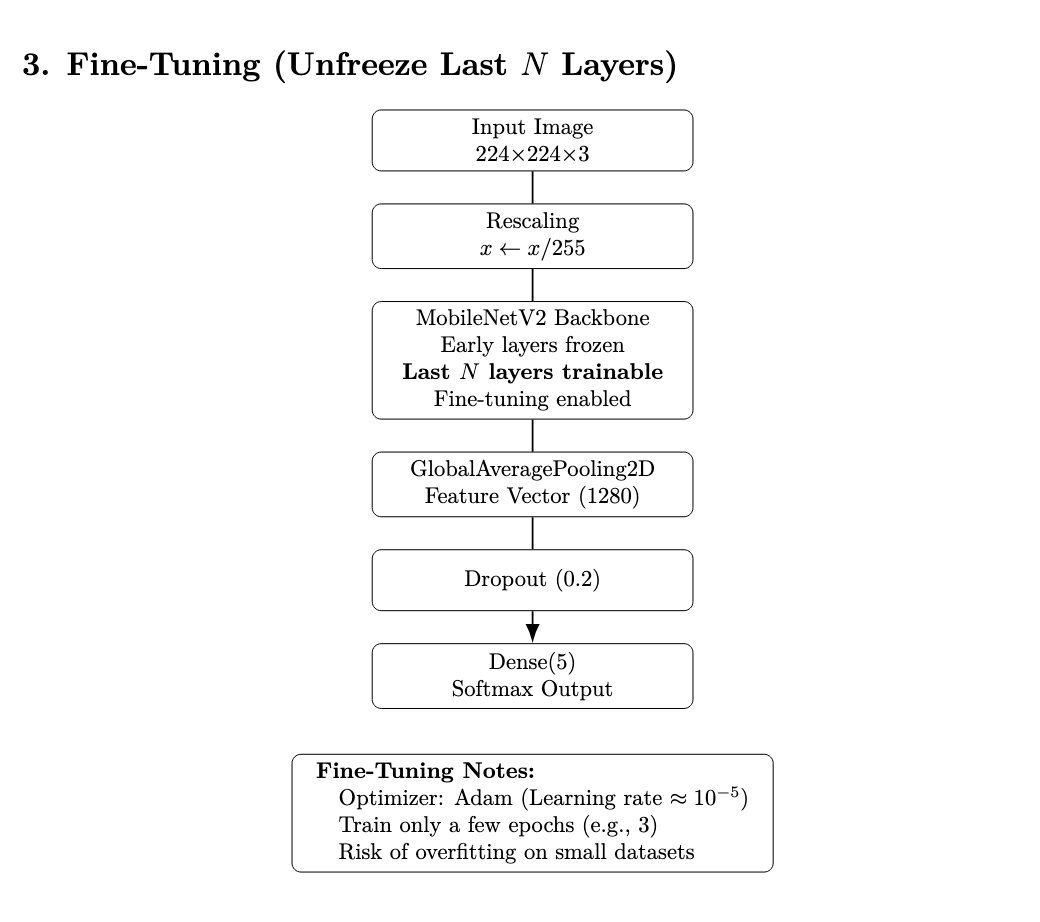

In [38]:
# Write the code here onwards

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

NUM_CLASSES = 5
IMG_SIZE = (224,224)

# Input layer
inputs = tf.keras.Input(shape=(224,224,3))

# Rescaling  x / 255
x = layers.Rescaling(1./255)(inputs)

# MobileNetV2 backbone
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze early layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers
N = 20
for layer in base_model.layers[-N:]:
    layer.trainable = True

# Pass through backbone
x = base_model(x, training=False)

# GlobalAveragePooling2D
x = layers.GlobalAveragePooling2D()(x)

# Feature vector size = 1280

# Dropout
x = layers.Dropout(0.2)(x)

# Dense Softmax output (5 classes)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

# Build model
model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_4 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,212,485 (4.63 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [43]:
EPOCHS = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4050 - loss: 1.4993 - val_accuracy: 0.5038 - val_loss: 1.2213
Epoch 2/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.6785 - loss: 0.8938 - val_accuracy: 0.6456 - val_loss: 0.9153
Epoch 3/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7766 - loss: 0.6579 - val_accuracy: 0.7197 - val_loss: 0.7387


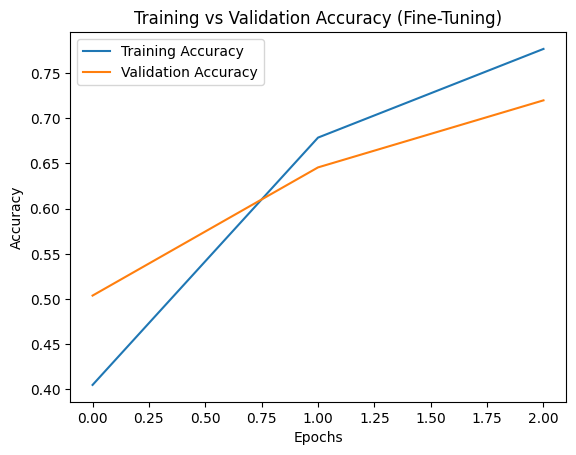

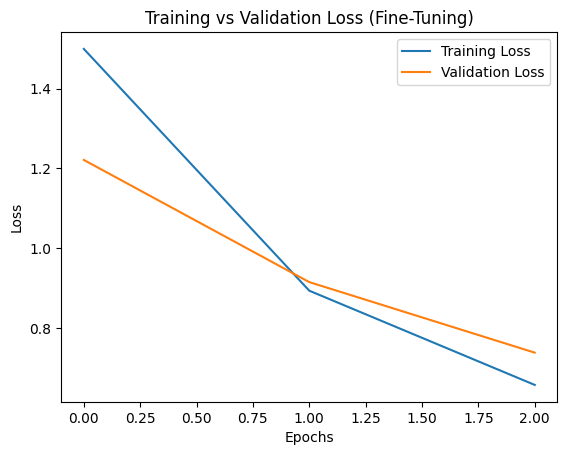

In [44]:
import matplotlib.pyplot as plt

# Accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(train_acc))

# Accuracy Chart
plt.figure()
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy (Fine-Tuning)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Chart
plt.figure()
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss (Fine-Tuning)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()